<a href="https://colab.research.google.com/github/BrunaLimaa/ImgSegmentation-IC/blob/SDUAISHD/notebooks/05_astrodendro_F0083_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install astrodendro
!pip install sep

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import simple_norm
import sep
import astrodendro
from astrodendro import Dendrogram
from astrodendro.analysis import pp_catalog
from astropy.io import fits
from astropy import units as u
from importlib.metadata import metadata
from astropy.io import fits
from astropy.wcs import WCS
from astropy.nddata import Cutout2D

Image loaded successfully.


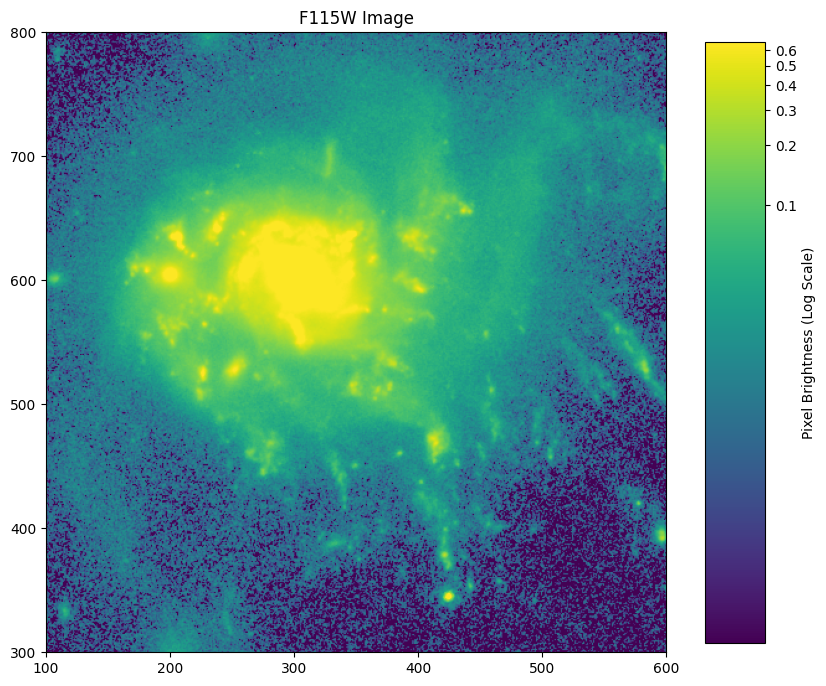

In [4]:

fits_file = '/content/F115W.fits'

try:
    with fits.open(fits_file) as hdul:

        raw_data = hdul[0].data
        image_data = raw_data.astype(float)

        print("Image loaded successfully.")

        # This first creates a mask to identify and ignore "bad" pixels (NaNs or zeros).
        good_pixel_mask = ~np.logical_or(np.isnan(image_data), image_data <= 0)

        # Then, it calculates the log stretch based ONLY on the good pixels.
        norm = simple_norm(image_data[good_pixel_mask], stretch='log', percent=98.5)

        # Display the image.
        fig, axes = plt.subplots(figsize=(10, 10))
        im = axes.imshow(image_data, cmap='viridis', origin='lower', norm=norm)
        fig.colorbar(im, label="Pixel Brightness (Log Scale)", shrink=0.78, aspect=10)
        axes.set_title("F115W Image")

        axes.set_xlim(100,600)
        axes.set_ylim(300,800)

        plt.show()

except FileNotFoundError:
    print(f"ERROR: File '{fits_file}' not found. Please ensure it is uploaded.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

In [5]:
from hashlib import new
if 'image_data' in locals():
    image_data_sep = image_data.astype(float)
    bkg = sep.Background(image_data_sep)
    background = sep.Background(image_data_sep)
    image_noBackground = image_data - background.back()

    # objects = sep.extract(image_noBackground, 1.5, err=bkg.globalrms)

    dendo = Dendrogram.compute(image_noBackground,
                               min_value=0.06,
                               min_delta=0.01,
                               min_npix=10)

    num_structures = len(dendo)
    num_leaves = len(dendo.leaves)
    print(f"Number of structures: {num_structures}")
    print(f"Number of leaves: {num_leaves}")

Number of structures: 249
Number of leaves: 148


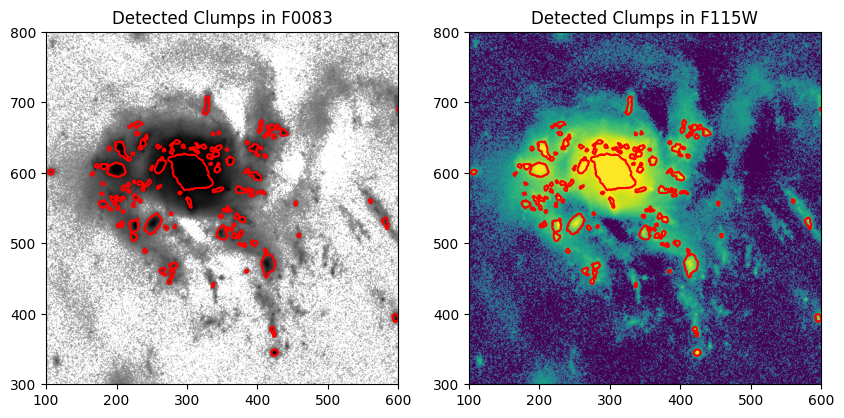

In [6]:
if 'dendo' in locals() and 'image_noBackground' in locals():
    leaves = dendo.leaves
    p = dendo.plotter()

    fig, ax = plt.subplots(1,2, figsize=(10, 10))

    good_pixel_mask = ~np.logical_or(np.isnan(image_noBackground), image_noBackground <= 0)
    norm = simple_norm(image_noBackground[good_pixel_mask], stretch='log', percent=98.5)
    im = ax[0].imshow(image_noBackground, cmap='gray_r', origin='lower', norm=norm)
    im2 = ax[1].imshow(image_noBackground, cmap='viridis', origin='lower',norm=norm)

    for axes in ax:
      axes.set_xlim(100,600)
      axes.set_ylim(300,800)


    for clump in leaves:
      p.plot_contour(ax[0], structure=clump, colors='red')
      p.plot_contour(ax[1], structure=clump, colors='red')
    ax[0].set_title("Detected Clumps in F0083")
    ax[1].set_title("Detected Clumps in F115W")
    plt.show()



In [7]:

if 'dendo' in locals():

    metadata = {}
    metadata['data_unit'] = u.Jy
    metadata['spacial_scale'] = 0.83 * u.arcsec

    print("Metadata for catalog is defined.")

    catalog = pp_catalog(dendo, metadata)
    print("Catalog is created.")

    catalog.keep_columns(['_idx', 'x_cen', 'y_cen', 'major_sigma', 'minor_sigma', 'flux'])

    # Renamed columns for clarity
    catalog.rename_column('_idx', 'Clump ID')
    catalog.rename_column('x_cen', 'X Center (pix)')
    catalog.rename_column('y_cen', 'Y Center (pix)')
    catalog.rename_column('major_sigma', 'Size Major (arcsec)')
    catalog.rename_column('minor_sigma', 'Size Minor (arcsec)')
    catalog.rename_column('flux', 'Total Flux (Jy)')


Metadata for catalog is defined.
Computing catalog for 249 structures

[>                                        ] 0%
[>                                        ] 0%
[>                                        ] 1%
[>                                        ] 1%
[>                                        ] 2%
[>                                        ] 2%
[=>                                       ] 2%
[=>                                       ] 3%
[=>                                       ] 3%
[=>                                       ] 4%
[=>                                       ] 4%
[=>                                       ] 4%
[==>                                      ] 5%
[==>                                      ] 5%
[==>                                      ] 6%
[==>                                      ] 6%
[==>                                      ] 6%
[==>                                      ] 7%
[===>                                     ] 7%
[===>                               

In [8]:
catalog.pprint(max_width=-1)

Clump ID  Total Flux (Jy)   Size Major (arcsec) Size Minor (arcsec)   X Center (pix)     Y Center (pix)  
                 Jy                 pix                 pix                pix                pix        
-------- ------------------ ------------------- ------------------- ------------------ ------------------
       0  2.072628270369023  1.4368323728027175  1.0065223109383536 222.66469527536623  27.84534526427253
       1  827.1596215375175   21.18751993564313   6.555078272475188   514.519621322171 131.44346975991803
       2 1.5373814166814554  1.5703896295909994  0.8735112837857272  829.7486957249654  72.32868105127393
       3  797.3413382103608  20.743675237825315   5.961546339144739  514.7321191658705  131.4861288847443
       4  4.380035477457568   3.376956973232856  0.8940669633146111 491.40272982920163   76.6653745824743
       5  7.242758197709918   4.876867743464504   1.083516425137268  492.7139215886514  78.94423786296413
       6 1.4383567092008889  1.555518986265726

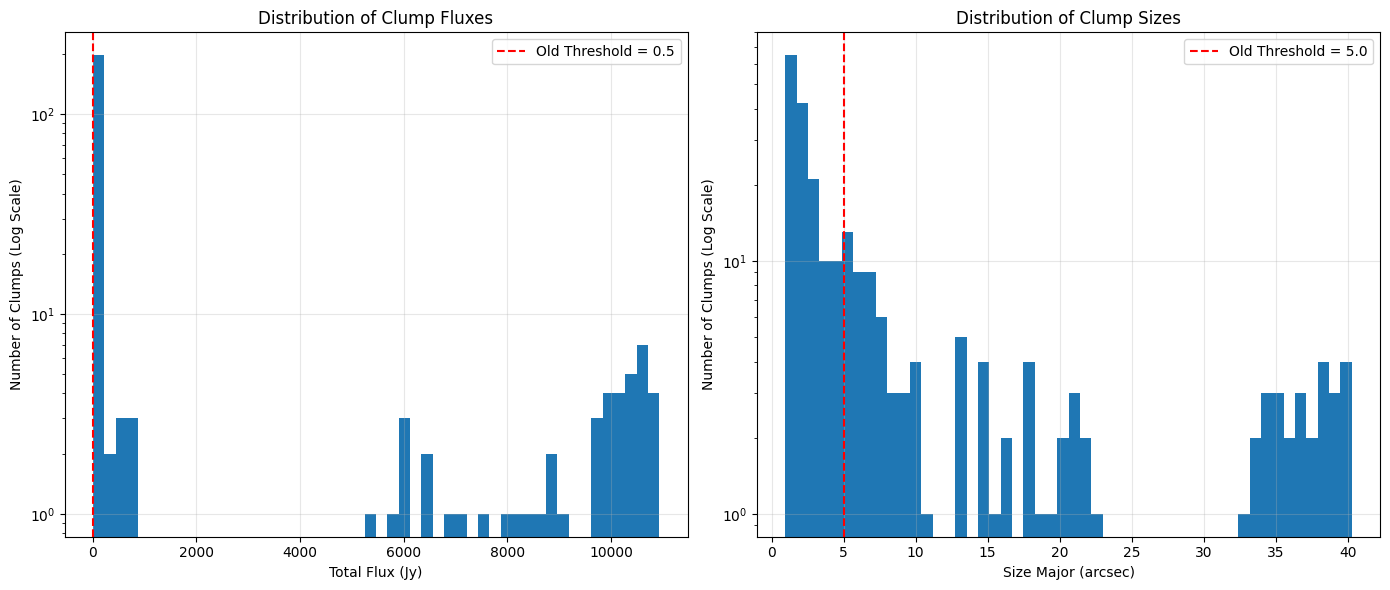

In [9]:
if 'catalog' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot a histogram of the FLUX of all detected clumps
    axes[0].hist(catalog['Total Flux (Jy)'], bins=50, log=True)
    axes[0].set_title("Distribution of Clump Fluxes")
    axes[0].set_xlabel("Total Flux (Jy)")
    axes[0].set_ylabel("Number of Clumps (Log Scale)")
    axes[0].grid(True, alpha=0.3)

    # Draw a vertical line showing our OLD, strict threshold
    axes[0].axvline(0.5, color='red', linestyle='--', label="Old Threshold = 0.5")
    axes[0].legend()

    # Plot a histogram of the SIZE of all detected clumps
    axes[1].hist(catalog['Size Major (arcsec)'], bins=50, log=True)
    axes[1].set_title("Distribution of Clump Sizes")
    axes[1].set_xlabel("Size Major (arcsec)")
    axes[1].set_ylabel("Number of Clumps (Log Scale)")
    axes[1].grid(True, alpha=0.3)

    # Draw a vertical line showing our OLD, strict threshold
    axes[1].axvline(5.0, color='red', linestyle='--', label="Old Threshold = 5.0")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

Original number of clumps (leaves): 249
Filtering criteria: Flux > 0.08 Jy AND Size > 1.0 arcsec
Clump ID  Total Flux (Jy)   Size Major (arcsec) Size Minor (arcsec)   X Center (pix)     Y Center (pix)  
                 Jy                 pix                 pix                pix                pix        
-------- ------------------ ------------------- ------------------- ------------------ ------------------
       0  2.072628270369023  1.4368323728027175  1.0065223109383536 222.66469527536623  27.84534526427253
       1  827.1596215375175   21.18751993564313   6.555078272475188   514.519621322171 131.44346975991803
       2 1.5373814166814554  1.5703896295909994  0.8735112837857272  829.7486957249654  72.32868105127393
       3  797.3413382103608  20.743675237825315   5.961546339144739  514.7321191658705  131.4861288847443
       4  4.380035477457568   3.376956973232856  0.8940669633146111 491.40272982920163   76.6653745824743
       5  7.242758197709918   4.876867743464504   1.083

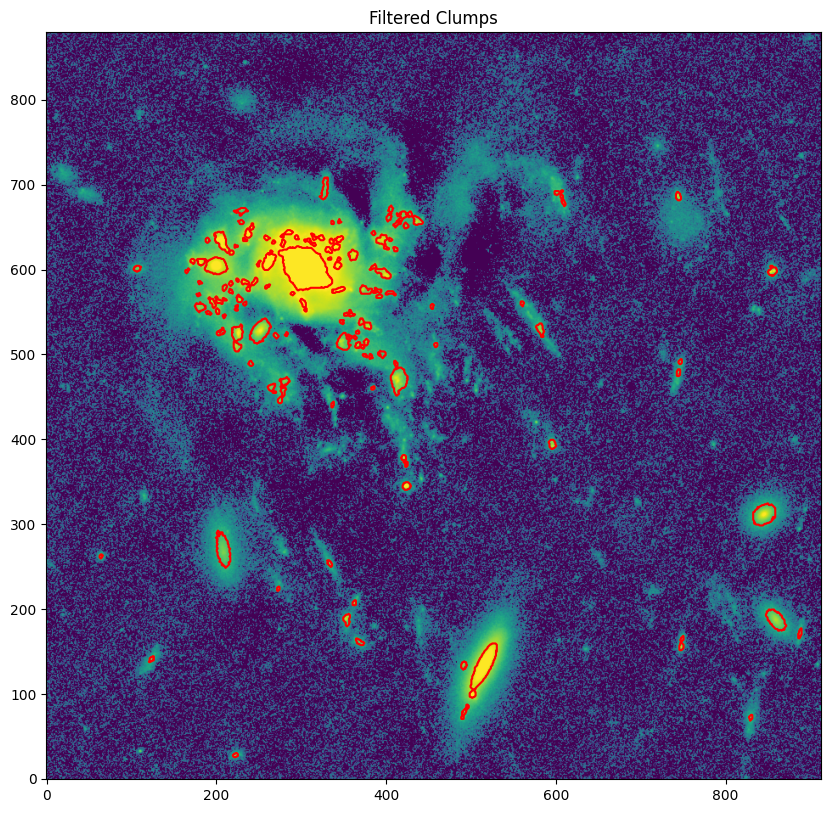

In [10]:
if 'catalog' in locals() and 'dendo' in locals():
    min_flux_threshold = 0.08
    min_size_threshold = 1.0

    print(f"Original number of clumps (leaves): {len(catalog)}")
    print(f"Filtering criteria: Flux > {min_flux_threshold} Jy AND Size > {min_size_threshold} arcsec")

    flux_filter = catalog['Total Flux (Jy)'] > min_flux_threshold
    size_filter = catalog['Size Major (arcsec)'] > min_size_threshold

    final_filter = flux_filter & size_filter
    filtered_catalog = catalog[final_filter]

    filtered_catalog.pprint(max_width=-1)
    print(f"Number of clumps (leaves) after filtering: {len(filtered_catalog)}")

    filtered_ids = filtered_catalog['Clump ID']

    filtered_leaves = [leaf for leaf in dendo.leaves
                            if leaf.idx in filtered_ids]

    p = dendo.plotter()

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(image_noBackground, cmap='viridis', origin='lower', norm=norm)

    if filtered_leaves:
        for clump in filtered_leaves:
          p.plot_contour(ax, structure=clump, colors='red')
    ax.set_title("Filtered Clumps")
    plt.show()


